# Fase 3b - Explicabilidad (SHAP)

Tener un modelo que dice "fraude 96%" no basta: en riesgo hay que justificar cada alerta. SHAP
reparte la predicción entre las features, así vemos qué empujó a cada transacción hacia fraude o
hacia legítima. La lógica está en `src/explain.py`; aquí la usamos sobre el modelo ya entrenado.

In [1]:
# Permite ejecutar el notebook desde cualquier carpeta (p.ej. con jupyter nbconvert):
# subimos hasta la raiz del proyecto y la anadimos al path para poder importar src/.
import sys
from pathlib import Path
_root = Path.cwd()
while not (_root / "config.yaml").exists() and _root != _root.parent:
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import pickle
import numpy as np
from src.config import load_config, path
from src import explain

cfg = load_config()
REPORTS = path(cfg["paths"]["reports"])
art = pickle.load(open(path(cfg["paths"]["model"]), "rb"))
splits = pickle.load(open(path(cfg["data"]["splits"]), "rb"))
model, features = art["model"], art["features"]
X_test = splits["X_test"]
print("Modelo:", art["model_name"], "| umbral guardado:", art.get("threshold"))

C:\Users\omar1\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Modelo: XGBoost | umbral guardado: 0.15000000000000002


## Visión global: qué mueve al modelo

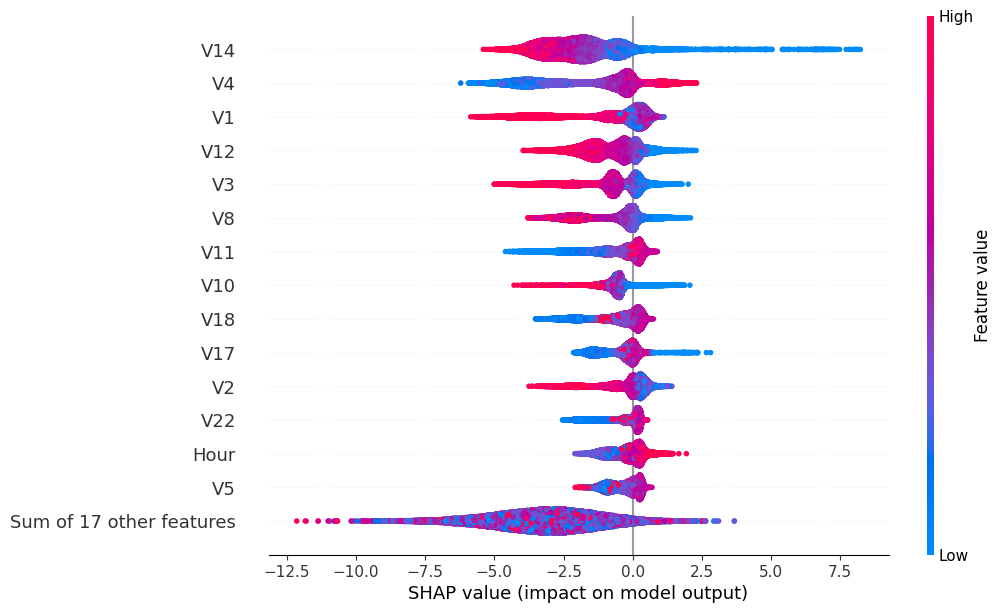

In [2]:
sv = explain.summary_figure(model, X_test, features, REPORTS / "12_shap_summary.png")
from IPython.display import Image
Image(filename=str(REPORTS / "12_shap_summary.png"))

Las features PCA con más peso (V14, V10, V12, V4...) coinciden con las que el EDA marcó como más correlacionadas con el fraude. Buena señal de coherencia.

## Por qué se marcó UNA transacción

Transaccion #18427: probabilidad de fraude 100.00%


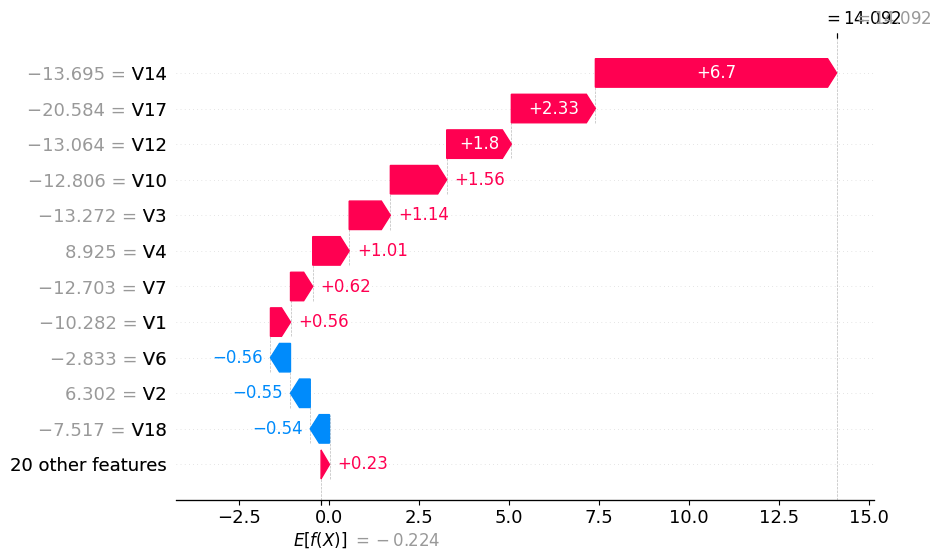

In [3]:
# Tomamos la transacción que el modelo ve como más sospechosa y la explicamos.
proba = model.predict_proba(np.ascontiguousarray(np.asarray(X_test, float)))[:, 1]
i = int(np.argmax(proba))
print(f"Transaccion #{i}: probabilidad de fraude {proba[i]:.2%}")
explain.waterfall_figure(sv, i, REPORTS / "13_shap_waterfall.png")
from IPython.display import Image
Image(filename=str(REPORTS / "13_shap_waterfall.png"))

## Lo que consumirá la API (CP5)

In [4]:
# top_contributions devuelve las features que más pesaron en una prediccion concreta.
# Es justo lo que la API/dashboard mostrará junto al veredicto.
x = np.asarray(X_test)[i]
for feat, val in explain.top_contributions(model, x, features, k=5):
    rumbo = "hacia FRAUDE" if val > 0 else "hacia legítima"
    print(f"  {feat:<12} {val:+.3f}  ({rumbo})")

  V14          +6.699  (hacia FRAUDE)
  V17          +2.333  (hacia FRAUDE)
  V12          +1.795  (hacia FRAUDE)
  V10          +1.565  (hacia FRAUDE)
  V3           +1.143  (hacia FRAUDE)


## Conclusión

Cada alerta deja de ser una caja negra: podemos enseñar las 3-5 features que la dispararon. Eso
es lo que hace usable un modelo de fraude en un equipo de revisión. La misma función
(`explain.top_contributions`) la reutilizará la API en el CP5.